In [1]:
import kagglehub
import pandas as pd
pd.set_option('display.max_columns', None)
import matplotlib.pyplot as plt
import seaborn as sns
import math
import os
os.makedirs('static/img', exist_ok=True)

c:\Users\computer\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
path = kagglehub.dataset_download("patelris/steam-top-1495-games-dataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\computer\.cache\kagglehub\datasets\patelris\steam-top-1495-games-dataset\versions\9


In [3]:
data = pd.read_csv("C:/Users/computer/.cache/kagglehub/datasets/patelris/steam-top-1495-games-dataset/versions/9/steam_top_games_2026.csv")

In [4]:
df = data.copy()
df.shape

(1495, 29)

In [5]:
df.head()

,app_id,name,release_date,coming_soon,price_usd,is_free,discount_pct,developer,publisher,genres,categories,tags,platforms_win,platforms_mac,platforms_linux,metacritic_score,recommendations,positive_reviews,negative_reviews,estimated_owners,avg_playtime_forever,avg_playtime_2weeks,median_playtime,peak_ccu,required_age,dlc_count,achievements,short_description,header_image
0,794260,Outward Definitive Edition,"May 17, 2022",False,4.79,False,88,Nine Dots Studio,"Prime Matter, Deep Silver",RPG,"Single-player, Multi-player, Co-op, Online Co-...","RPG, Open World, Survival, Co-op, Online Co-Op...",True,False,False,NaN,23986,20738,7717,"1,000,000 .. 2,000,000",1332,824,465,469,0,1,72,No remarkable journey is achieved without grea...,https://shared.akamai.steamstatic.com/store_it...
1,253920,Gorky 17,"Sep 27, 2013",False,9.99,False,0,Metropolis Software,TopWare Interactive,"RPG, Strategy","Single-player, Steam Trading Cards, Family Sha...","RPG, Strategy, Turn-Based, Classic, Horror, Po...",True,True,True,NaN,909,1616,411,"200,000 .. 500,000",301,0,328,61,17,2,0,November 2008. NATO intelligence services repo...,https://shared.akamai.steamstatic.com/store_it...
2,613010,Secret in Story,"Jun 19, 2017",False,0.89,False,10,Naivus Luo,Naivus Luo,"Adventure, Indie","Single-player, Steam Achievements, Steam Tradi...","Indie, Adventure, Visual Novel",True,True,False,NaN,0,79,35,"2,000,000 .. 5,000,000",251,0,243,0,0,0,32,"Accompanied by beautiful piano music, you begi...",https://shared.akamai.steamstatic.com/store_it...
3,892420,懒人修仙传,"Nov 14, 2018",False,3.99,False,0,托更的修罗,托更的修罗,"Casual, Indie, RPG, Simulation","Single-player, Family Sharing","Simulation, Casual, RPG, Indie, Word Game, Idler",True,False,False,NaN,1169,769,509,"200,000 .. 500,000",5786,0,9223,41,0,0,0,这是一款很&quot;休闲&quot;的文字挂机游戏，游戏小而系统完善，玩法丰富，极其耗电，...,https://shared.akamai.steamstatic.com/store_it...
4,914010,Train Station Renovation,"Oct 1, 2020",False,18.99,False,0,Live Motion Games,"Live Motion Games, Frozen Way, PlayWay S.A., F...","Casual, Indie, Simulation","Single-player, Steam Achievements, Steam Cloud...","Simulation, Casual, Indie, Trains, First-Perso...",True,False,False,68.0,1948,2154,466,"200,000 .. 500,000",448,0,201,16,0,1,73,"Welcome to an old, ruined train station. A pla...",https://shared.akamai.steamstatic.com/store_it...


In [6]:
df.columns

Index(['app_id', 'name', 'release_date', 'coming_soon', 'price_usd', 'is_free',
       'discount_pct', 'developer', 'publisher', 'genres', 'categories',
       'tags', 'platforms_win', 'platforms_mac', 'platforms_linux',
       'metacritic_score', 'recommendations', 'positive_reviews',
       'negative_reviews', 'estimated_owners', 'avg_playtime_forever',
       'avg_playtime_2weeks', 'median_playtime', 'peak_ccu', 'required_age',
       'dlc_count', 'achievements', 'short_description', 'header_image'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1495 entries, 0 to 1494
Data columns (total 29 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   app_id                1495 non-null   int64  
 1   name                  1495 non-null   object 
 2   release_date          1488 non-null   object 
 3   coming_soon           1495 non-null   bool   
 4   price_usd             1495 non-null   float64
 5   is_free               1495 non-null   bool   
 6   discount_pct          1495 non-null   int64  
 7   developer             1487 non-null   object 
 8   publisher             1483 non-null   object 
 9   genres                1487 non-null   object 
 10  categories            1486 non-null   object 
 11  tags                  1489 non-null   object 
 12  platforms_win         1495 non-null   bool   
 13  platforms_mac         1495 non-null   bool   
 14  platforms_linux       1495 non-null   bool   
 15  metacritic_score     

# handle NULL value

In [8]:
((df.isnull().sum() / len(df)) * 100)[df.isnull().sum() > 0]

release_date          0.468227
developer             0.535117
publisher             0.802676
genres                0.535117
categories            0.602007
tags                  0.401338
metacritic_score     63.879599
estimated_owners      0.334448
short_description     0.133779
header_image          0.066890
dtype: float64

In [9]:
def handleNull(df: pd.DataFrame)-> pd.DataFrame:
    """
        handle null value in df in 3 way:
        - less than 5%: del sample
        - less than 20%: fill empty with mode / median based on type
        - else: del column
    """
    df_clean = df.copy()

    null_per = ((df_clean.isnull().sum() / len(df_clean)) * 100)

    for col in df_clean.columns:
        pct = null_per[col]

        if pct > 0:
            if pct < 5:
                df_clean = df_clean.dropna(subset=[col])
                
            elif pct <= 20:
                if df_clean[col].dtype == 'object':
                    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])
                else:
                    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

            else:
                df_clean = df_clean.drop(col, axis=1)
                
    return df_clean

In [10]:
df = handleNull(df)

In [11]:
df.isnull().sum()[df.isnull().sum() > 0]

Series([], dtype: int64)

In [12]:
df.shape

(1450, 28)

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df["name"].value_counts()

name
Time Gentlemen, Please! and Ben There, Dan That! Special Edition  Double Pack    2
Call of Duty®: WWII                                                              2
Mushroom Wars 2                                                                  1
The Crew™ 2                                                                      1
The Hat Man: Shadow Ward                                                         1
                                                                                ..
Zup!                                                                             1
X Rebirth                                                                        1
Conquest of Elysium 5                                                            1
Mount Your Friends                                                               1
Iron Lung                                                                        1
Name: count, Length: 1448, dtype: int64

In [15]:
df = df.sort_values(by='positive_reviews', ascending=False).reset_index(drop=True)
df = df.drop_duplicates(subset=['name'], keep='first')

In [16]:
df_interface = df[["name", "short_description", "header_image", "categories", "genres"]].copy()

In [17]:
del df["app_id"], df["short_description"], df["header_image"]

In [18]:
df.head()

,name,release_date,coming_soon,price_usd,is_free,discount_pct,developer,publisher,genres,categories,tags,platforms_win,platforms_mac,platforms_linux,recommendations,positive_reviews,negative_reviews,estimated_owners,avg_playtime_forever,avg_playtime_2weeks,median_playtime,peak_ccu,required_age,dlc_count,achievements
0,Counter-Strike 2,"Aug 21, 2012",False,0.00,True,0,Valve,Valve,"Action, Free To Play","Multi-player, Cross-Platform Multiplayer, Stea...","FPS, Shooter, Multiplayer, Competitive, Action...",True,False,True,5037443,7642084,1173003,"100,000,000 .. 200,000,000",34018,676,6289,1013936,0,1,1
1,Rust,"Feb 8, 2018",False,39.99,False,0,Facepunch Studios,Facepunch Studios,"Action, Adventure, Indie, Massively Multiplaye...","Multi-player, MMO, PvP, Online PvP, Co-op, Onl...","Survival, Crafting, Multiplayer, Open World, O...",True,True,False,1126145,1071135,156649,"20,000,000 .. 50,000,000",20315,1157,3043,143870,0,5,102
2,Baldur's Gate 3,"Aug 3, 2023",False,59.99,False,0,Larian Studios,Larian Studios,"Adventure, RPG, Strategy","Single-player, Multi-player, Co-op, Online Co-...","RPG, Character Customization, Choices Matter, ...",True,True,False,734964,736688,23974,"20,000,000 .. 50,000,000",7794,685,4392,54771,17,2,54
3,Phasmophobia,"Sep 18, 2020",False,19.99,False,0,Kinetic Games,Kinetic Games,"Action, Indie, Early Access","Single-player, Multi-player, Co-op, Online Co-...","Horror, Online Co-Op, Multiplayer, Psychologic...",True,False,False,666253,736611,32168,"10,000,000 .. 20,000,000",2371,199,915,9978,0,0,54
4,Dead by Daylight,"Jun 14, 2016",False,19.99,False,0,Behaviour Interactive Inc.,Behaviour Interactive Inc.,Action,"Multi-player, PvP, Online PvP, Co-op, Online C...","Horror, Multiplayer, Survival Horror, Online C...",True,False,False,652542,630223,166993,"20,000,000 .. 50,000,000",13481,844,1448,44886,17,37,297


# handle columns value

In [19]:
def clean_e_owners(val):
    val = str(val).replace(',', '')
    if '..' in val:
        low, high = val.split('..')
        return (float(low) + float(high)) / 2
    return float(val)

df['estimated_owners'] = df['estimated_owners'].apply(clean_e_owners)

In [20]:
text_cols = ["developer", "publisher", "genres", "categories", "tags"]

df[text_cols] = df[text_cols].apply(lambda col: col.str.strip().str.lower())


df["developer"] = df["developer"].str.replace(r"feral interactive \((mac|linux)\)", "feral interactive", regex=True)
df["developer"] = df["developer"].str.replace("capcom co.", "capcom", regex=False)

# ------------

developer_df  = df["developer"].str.get_dummies(sep=", ").add_prefix("dev_").astype(bool)
publisher_df  = df["publisher"].str.get_dummies(sep=", ").add_prefix("pub_").astype(bool)
genres_df     = df["genres"].str.get_dummies(sep=", ").add_prefix("genres_").astype(bool)
categories_df = df["categories"].str.get_dummies(sep=", ").add_prefix("cat_").astype(bool)
tags_df       = df["tags"].str.get_dummies(sep=", ").add_prefix("tag_").astype(bool)


df = pd.concat([df, developer_df, publisher_df, genres_df, categories_df, tags_df], axis=1)

del df["developer"], df["publisher"], df["genres"], df["categories"], df["tags"]

# --------------------
legal_suffixes = {"inc", "inc.", "llc", "llc.","ltd", "ltd.", "llp", "llp."}
df.drop(columns=[c for c in df.columns if c.replace("dev_", "").replace("pub_", "") in legal_suffixes],inplace=True)

In [21]:
developer  = [col for col in df.columns if col.startswith('dev_')]
publisher  = [col for col in df.columns if col.startswith('pub_')]
genres     = [col for col in df.columns if col.startswith('genres_')]
categories = [col for col in df.columns if col.startswith('cat_')]
tags       = [col for col in df.columns if col.startswith('tag_')]

print(f"developer len: {len(developer)}")
print(f"publisher len: {len(publisher)}")
print(f"genres len: {len(genres)}")
print(f"categories len: {len(categories)}")
print(f"tags len: {len(tags)}")

developer len: 1291
publisher len: 926
genres len: 24
categories len: 56
tags len: 398


In [22]:
df["coming_soon"].nunique()

1

In [23]:
df["platforms_win"].nunique()

1

In [24]:
def drop_constant(df: pd.DataFrame) -> pd.DataFrame:
    df_clean = df.copy()
    constant_cols = []
    
    for col in df_clean.columns:
        unique_count = df_clean[col].nunique()
        
        if unique_count == 1:
            constant_cols.append(col)
            
    if constant_cols:
        df_clean = df_clean.drop(columns=constant_cols)
        
    return df_clean

In [25]:
df = drop_constant(df)

In [26]:
df['release_date'] = df['release_date'].astype(str).str.extract(r'(19\d{2}|20\d{2})')
df['release_date'] = pd.to_numeric(df['release_date'], errors='coerce')
df['release_date'] = df['release_date'].fillna(df['release_date'].median()).astype(int)

df = df.rename(columns={'release_date': 'release_year'})

In [27]:
df['price_usd'] = df['price_usd'] * 3.75
df = df.rename(columns={'price_usd': 'price_sar'})

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1448 entries, 0 to 1449
Columns: 2713 entries, name to tag_zombies
dtypes: bool(2698), float64(2), int64(12), object(1)
memory usage: 3.9+ MB


In [29]:
df.head(10)

name  release_year  price_sar  is_free  discount_pct  \
0       Counter-Strike 2          2012     0.0000     True             0   
1                   Rust          2018   149.9625    False             0   
2        Baldur's Gate 3          2023   224.9625    False             0   
3           Phasmophobia          2020    74.9625    False             0   
4       Dead by Daylight          2016    74.9625    False             0   
5  ARK: Survival Evolved          2017    37.0875    False            34   
6               Warframe          2013     0.0000     True             0   
7               Unturned          2017     0.0000     True             0   
8                Valheim          2021    74.9625    False             0   
9            Dying Light          2015    93.7125    False             0   

   platforms_mac  platforms_linux  recommendations  positive_reviews  \
0          False             True          5037443           7642084   
1           True            False          1126145           1071135   
2           True            False           734964            736688   
3          False            False           666253            736611   
4          False            False           652542            630223   
5           True            False           575975            612177   
6          False            False             2881            545393   
7           True             True             7524            506516   
8           True             True           450092            471451   
9           True             True           369315            435687   

   negative_reviews  estimated_owners  avg_playtime_forever  \
0           1173003       150000000.0                 34018   
1            156649        35000000.0                 20315   
2             23974        35000000.0                  7794   
3             32168        15000000.0                  2371   
4            166993        35000000.0                 13481   
5            117993        35000000.0                 12691   
6             81110        35000000.0                 14399   
7             48852        75000000.0                  8630   
8             28377        15000000.0                  4571   
9             21945        15000000.0                  2154   

   avg_playtime_2weeks  median_playtime  peak_ccu  required_age  dlc_count  \
0                  676             6289   1013936             0          1   
1                 1157             3043    143870             0          5   
2                  685             4392     54771            17          2   
3                  199              915      9978             0          0   
4                  844             1448     44886            17         37   
5                 2303              971     22170             0         18   
6                 1056              550     36195            17         17   
7                 3875              326     10408             0          1   
8                  876             1699     14439             0          1   
9                  297             1073      4953            17         41   

   achievements  dev_101xp game studios  dev_11 bit studios  \
0             1                   False               False   
1           102                   False               False   
2            54                   False               False   
3            54                   False               False   
4           297                   False               False   
5            32                   False               False   
6           193                   False               False   
7            88                   False               False   
8             0                   False               False   
9            78                   False               False   

   dev_1c game studios  dev_2k australia  dev_2k boston  dev_2k marin  \
0                False             False          False         False 

# ..

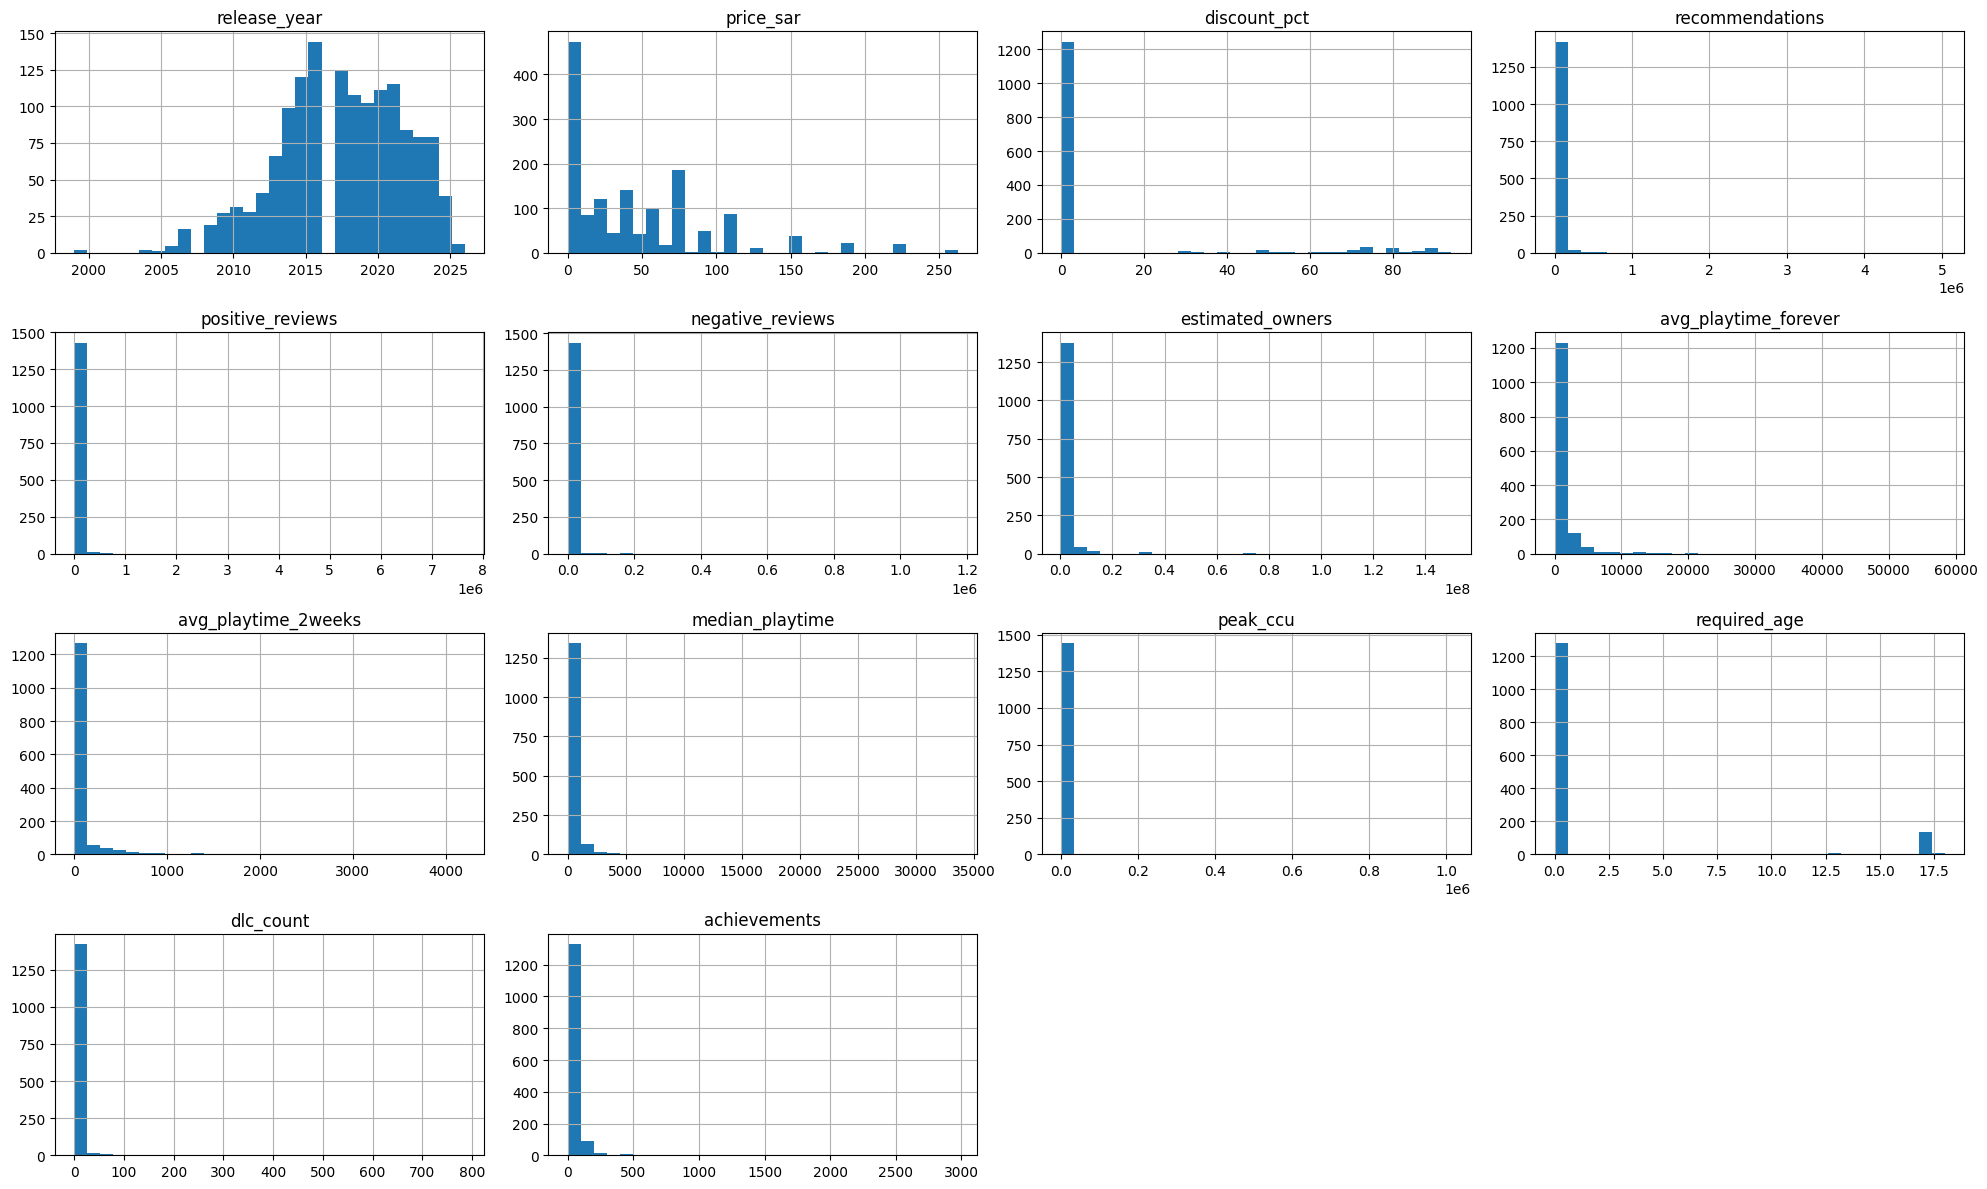

In [30]:
df.select_dtypes(include=["int64", "float64"]).hist(
    figsize=(20, 12),
    bins=30
)

plt.tight_layout()
plt.savefig('static/img/chart1_hist.png', dpi=300, bbox_inches='tight')
plt.show()

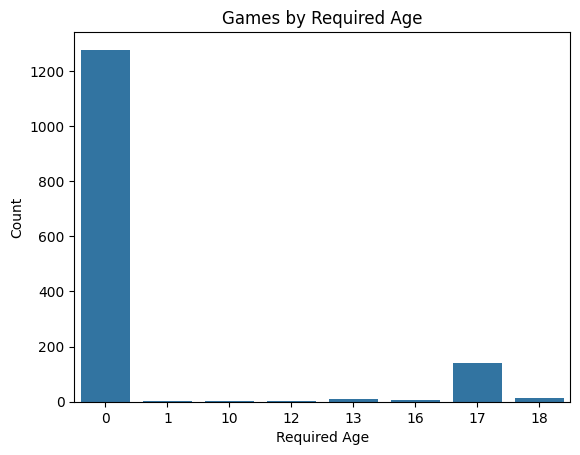

In [31]:
sns.countplot(data=df, x="required_age", order=sorted(df["required_age"].unique()))
plt.title("Games by Required Age")
plt.xlabel("Required Age")
plt.ylabel("Count")
plt.savefig('static/img/chart2_age.png', dpi=300, bbox_inches='tight')
plt.show()

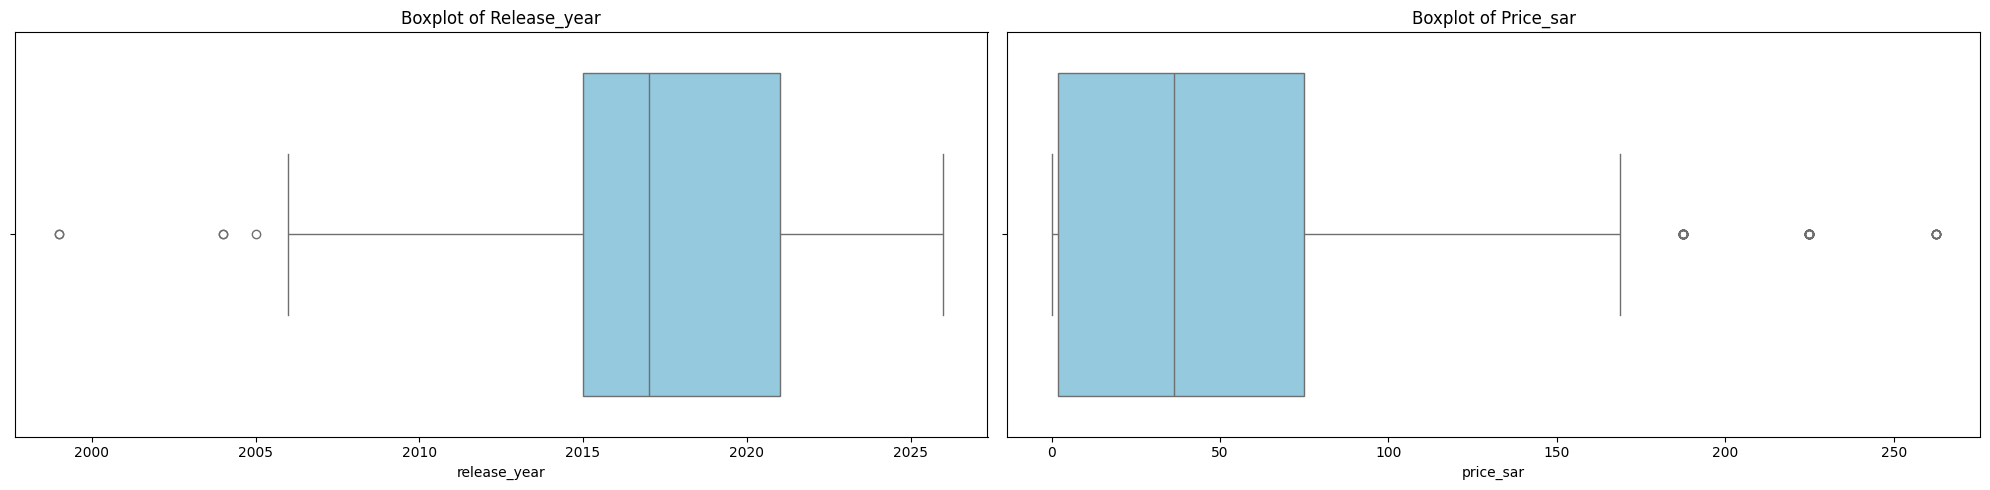

In [32]:
num_cols = ['release_year', 'price_sar']

fig, axes = plt.subplots(1, 2, figsize=(20, 5))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x=col, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Boxplot of {col.capitalize()}', fontsize=12)
    axes[i].set_xlabel(col)

plt.tight_layout()
plt.savefig('static/img/chart3_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

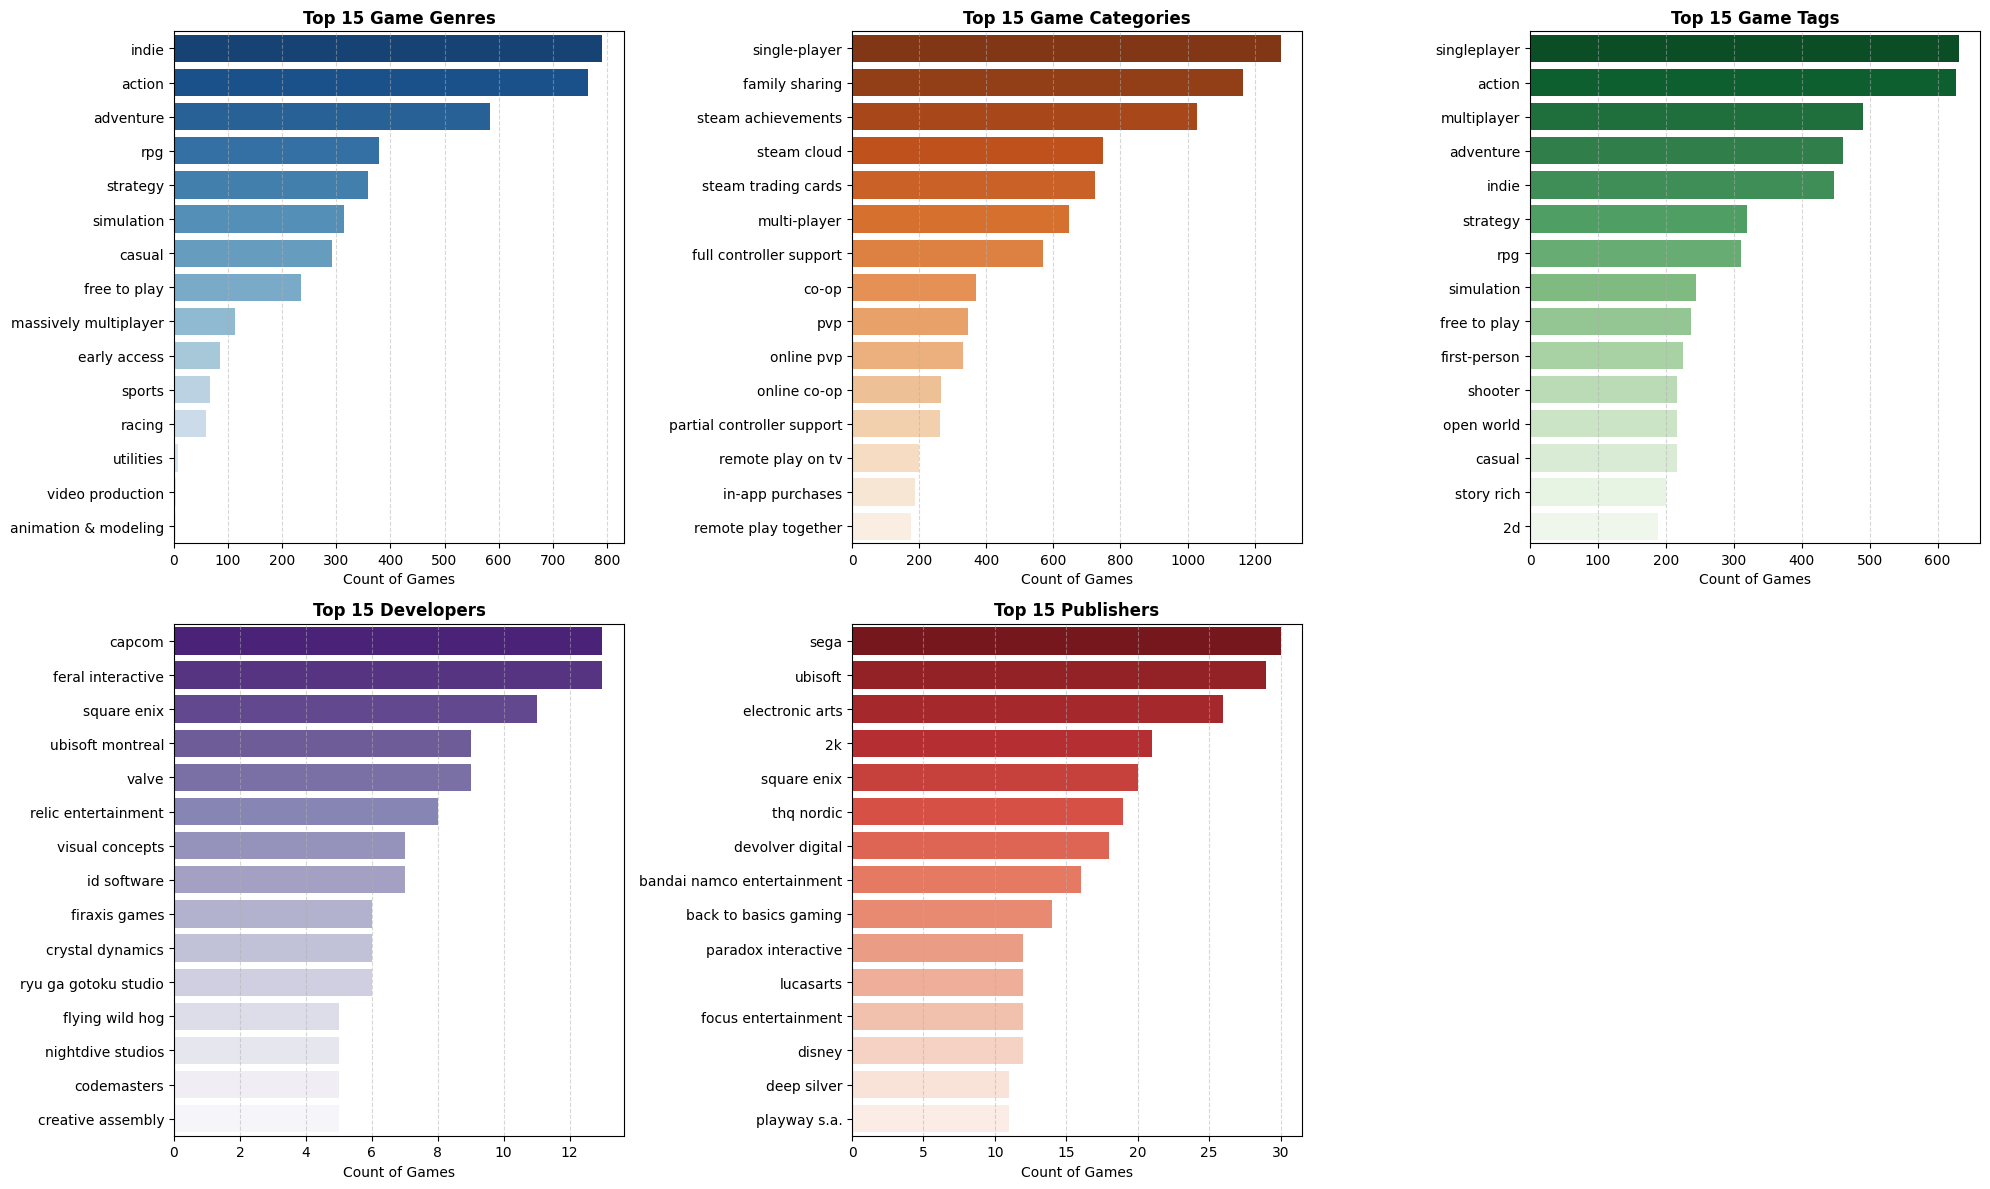

In [33]:
plots = [
    (genres, "genres_", "Top 15 Game Genres", "Blues_r"),
    (categories, "cat_", "Top 15 Game Categories", "Oranges_r"),
    (tags, "tag_", "Top 15 Game Tags", "Greens_r"),
    (developer, "dev_", "Top 15 Developers", "Purples_r"),
    (publisher, "pub_", "Top 15 Publishers", "Reds_r")
]

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for ax, (cols, prefix, title, palette) in zip(axes, plots):

    top = df[cols].sum().sort_values(ascending=False).head(15)
    top.index = top.index.str.replace(prefix, "", regex=False)

    sns.barplot(
        x=top.values,
        y=top.index,
        hue=top.index,
        palette=palette,
        legend=False,
        ax=ax
    )

    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Count of Games")
    ax.set_ylabel("")
    ax.grid(axis="x", linestyle="--", alpha=0.5)


fig.delaxes(axes[-1])

plt.tight_layout()
plt.savefig('static/img/chart4_categ.png', dpi=300, bbox_inches='tight')
plt.show()

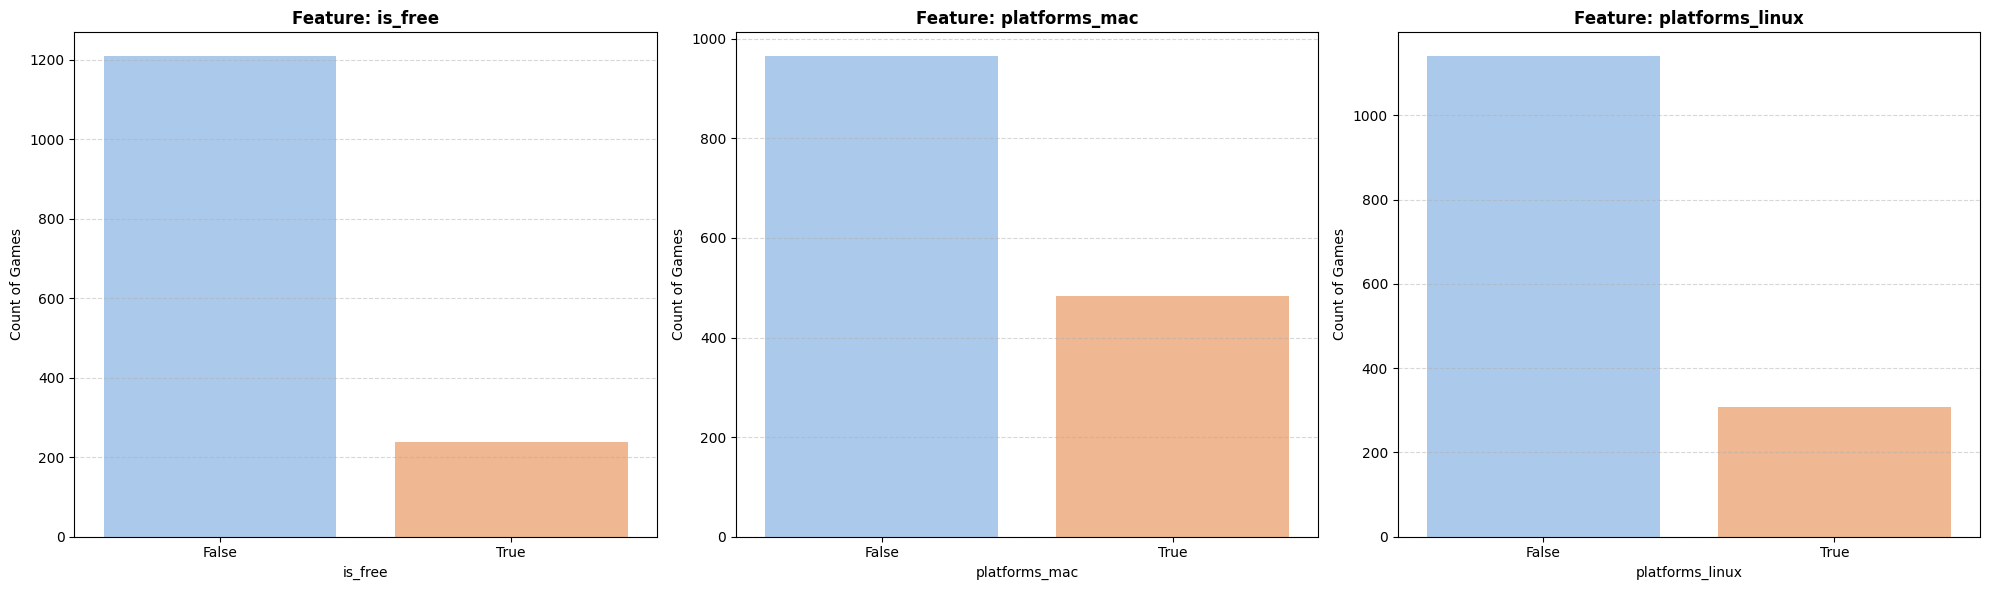

In [34]:
bool_cols = df.select_dtypes(include=['bool']).columns.tolist()

features_to_plot = [col for col in bool_cols if not (col.startswith('genres_') or col.startswith('cat_') or col.startswith('tag_') or col.startswith('dev_') or col.startswith('pub_'))]

n_bool_grid = len(features_to_plot)
fig, axes = plt.subplots(nrows=1, ncols=n_bool_grid, figsize=(20, 6))

axes = axes.flatten()
    
for i, col in enumerate(features_to_plot):
    sns.countplot(data=df, x=col, hue=col, palette='pastel', legend=False, ax=axes[i])
    axes[i].set_title(f'Feature: {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count of Games')
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)
    
plt.tight_layout()
plt.savefig('static/img/chart5_bool.png', dpi=300, bbox_inches='tight')
plt.show()

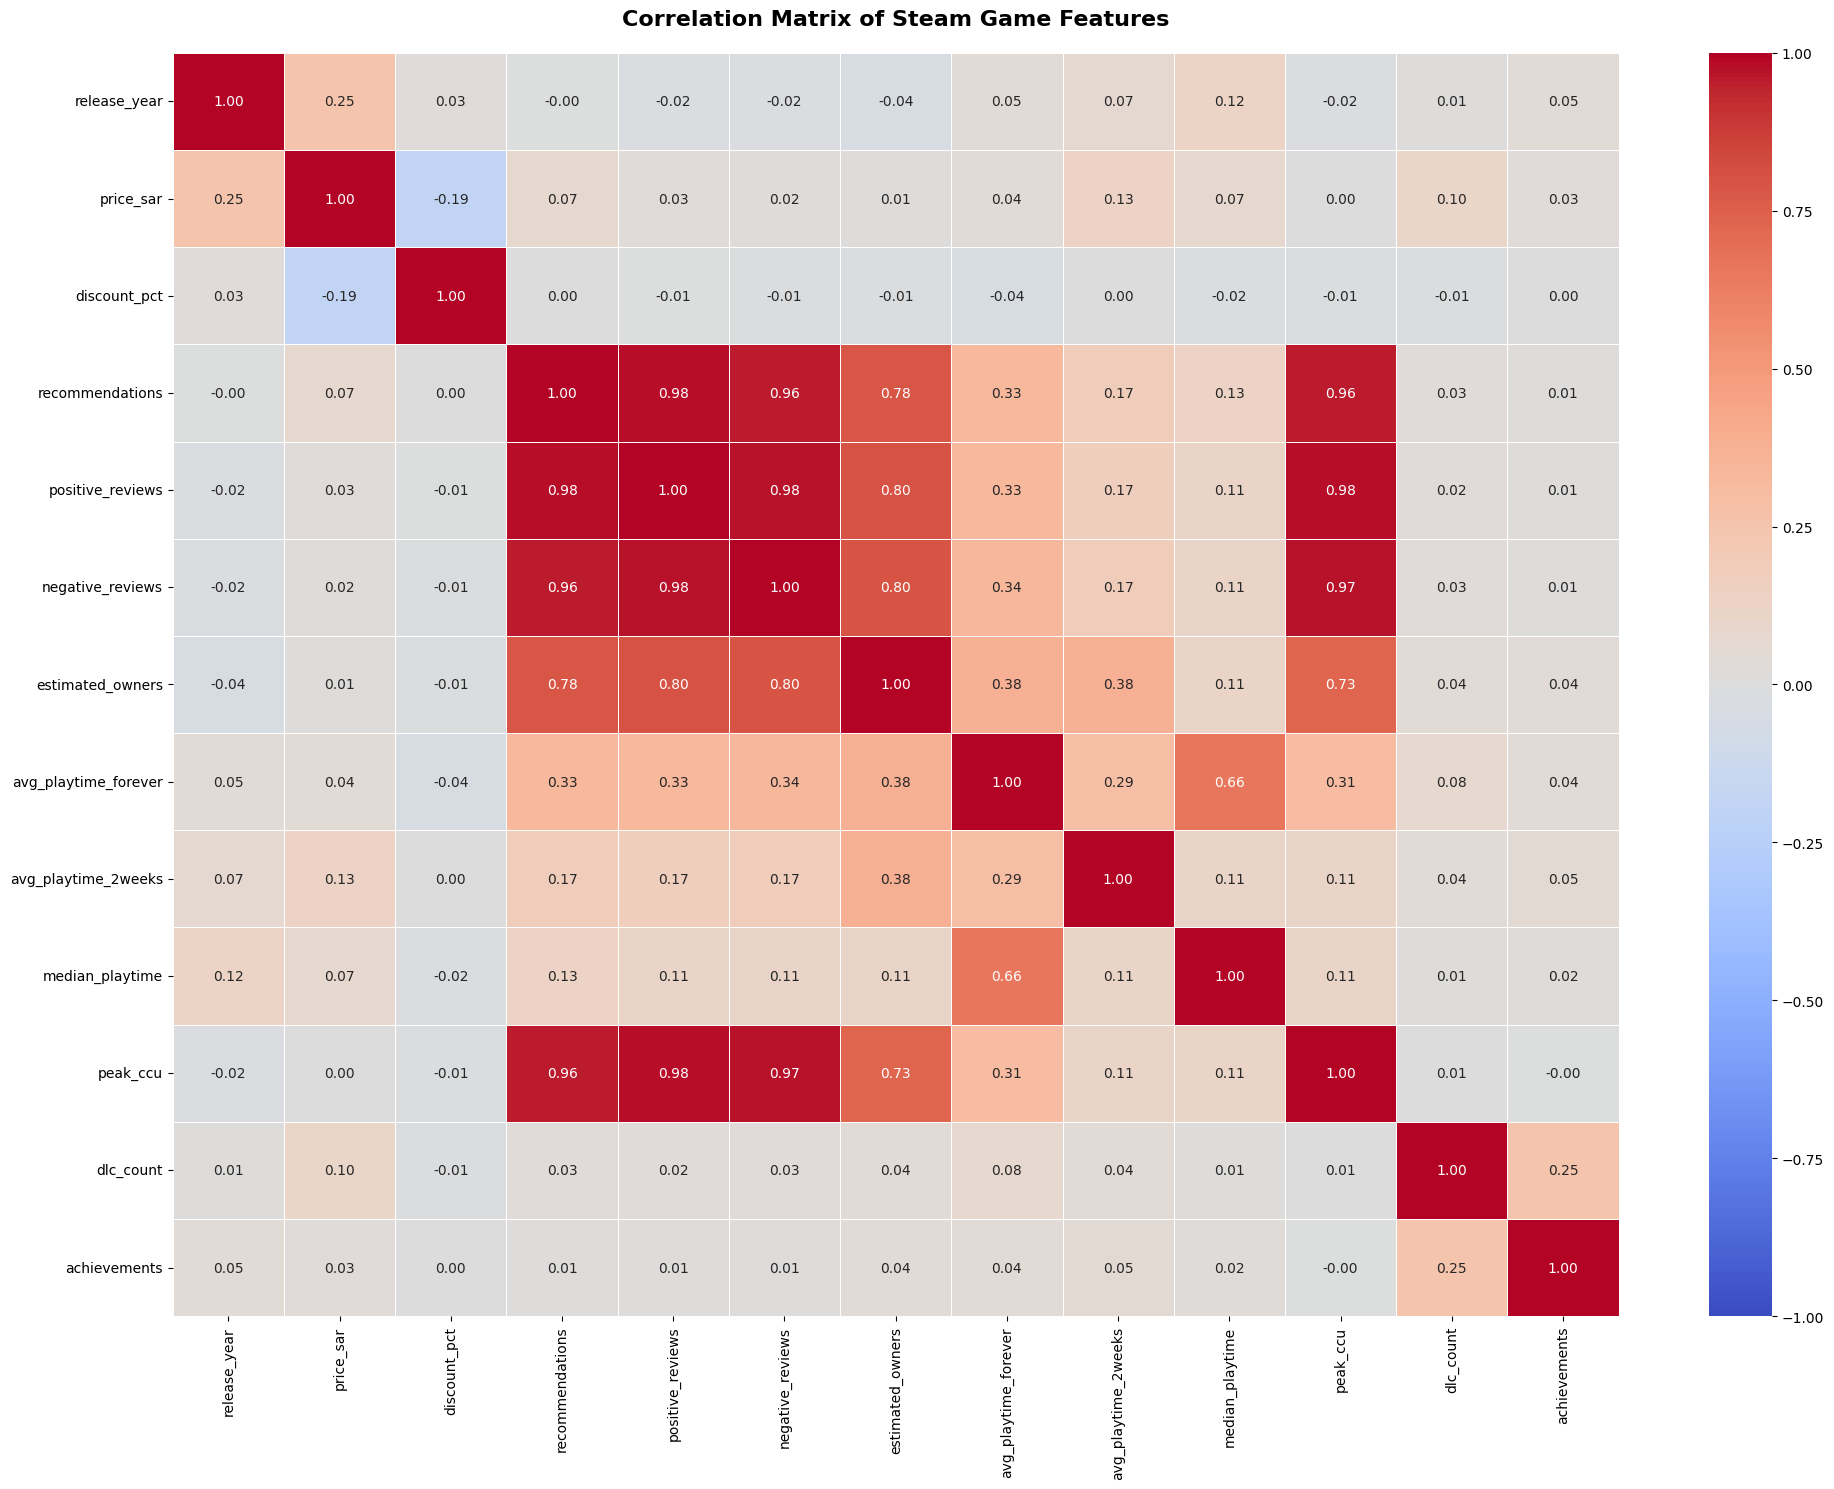

In [35]:
corr_matrix = df.select_dtypes(include=['number']).drop(columns=['required_age'], errors='ignore').corr()

plt.figure(figsize=(20, 15))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)

plt.title('Correlation Matrix of Steam Game Features', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('static/img/chart6_corr.png', dpi=300, bbox_inches='tight')
plt.show()

In [36]:
df_interface.to_csv("dataset/interface_data.csv", index=False)
df.to_csv("dataset/clean_data.csv", index=False)

# model

In [37]:
def recommend(game_name, age=18, n_recommendations=5):

    game_name = game_name.lower()

    matches = df[df["name"].str.lower() == game_name]

    if matches.empty:
        return None

    game_idx = matches.index[0]

    cluster = df.loc[game_idx, "cluster"]

    cluster_indices = df[df["cluster"] == cluster].index

    distances, indices = knn.kneighbors(
        X_pca[game_idx].reshape(1, -1),
        n_neighbors=len(df)
    )

    results = []

    for distance, idx in zip(distances[0], indices[0]):

        if idx == game_idx:
            continue

        if idx not in cluster_indices:
            continue

        if df.loc[idx, "required_age"] > age:
            continue

        results.append({
            "name": df.loc[idx, "name"],
            "similarity": round((1 - distance) * 100, 2)
        })

        if len(results) == n_recommendations:
            break

    return pd.DataFrame(results)

In [38]:
# a = recommend("dead by daylight", age=20)
#a